## Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn import linear_model
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error,r2_score

## Data Cleaning (Minimal)

In [2]:
df = pd.read_csv("../datasets/advertising.csv")
df.head(10)

,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9
5,6,8.7,48.9,75.0,7.2
6,7,57.5,32.8,23.5,11.8
7,8,120.2,19.6,11.6,13.2
8,9,8.6,2.1,1.0,4.8
9,10,199.8,2.6,21.2,10.6


In [3]:
df=df.drop(df.columns[0],axis=1)
df.head(5)

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [4]:
df.isnull().sum()

TV           0
radio        0
newspaper    0
sales        0
dtype: int64

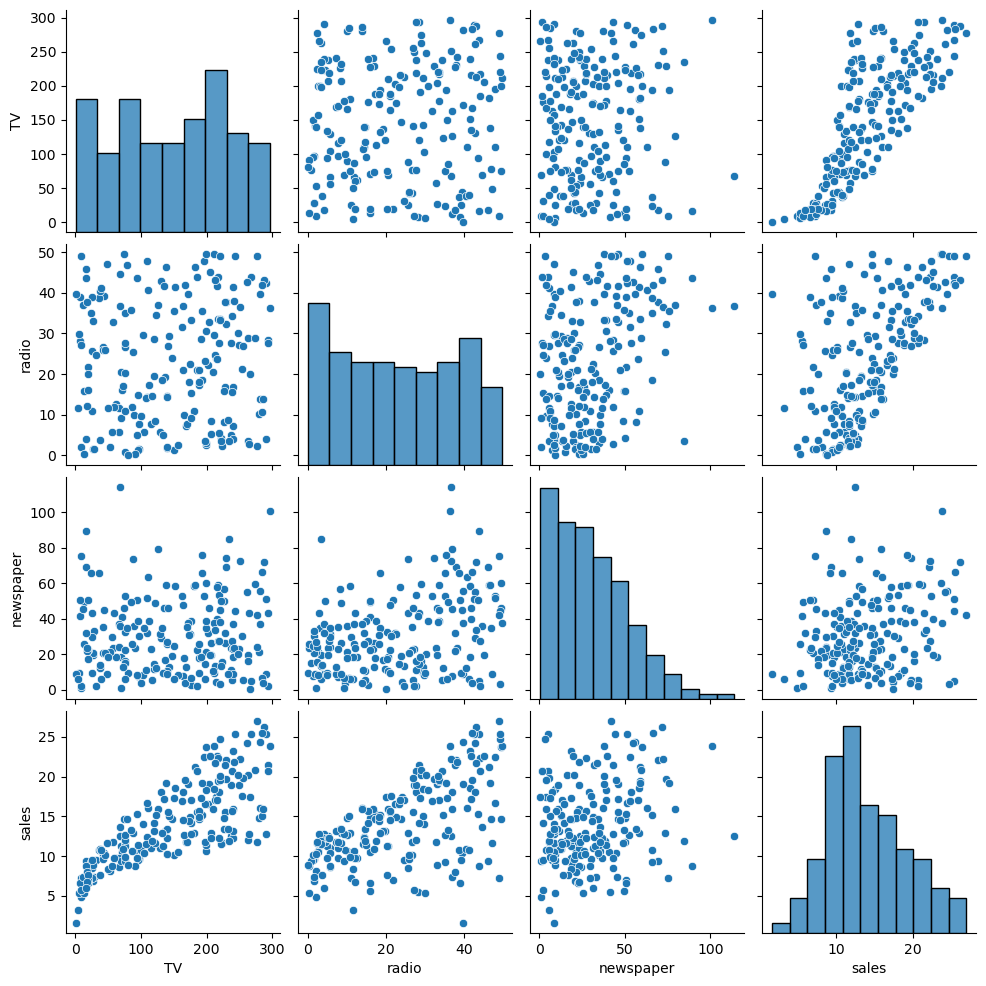

In [5]:
sns.pairplot(df)

## SLR with Radio to predict Sales

This is defualt ols regression.

In [6]:
#okay very important, we wanna predict y(so y is dependant), with independant variables x
X = df[["radio"]] 
y = df["sales"]

In [7]:
#dont need to scale this one

In [8]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
model=linear_model.LinearRegression()

In [9]:
model.fit(X_train,y_train)

LinearRegression()

[]

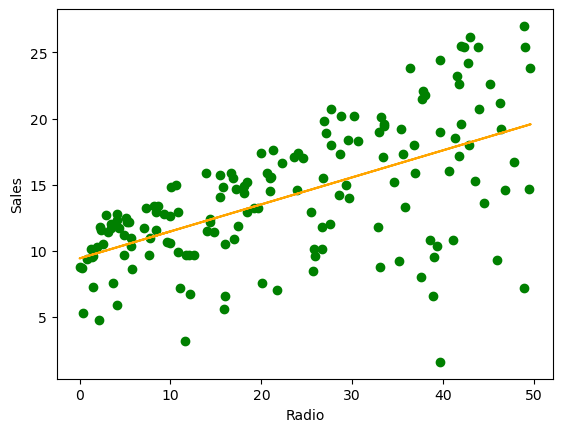

In [10]:
plt.scatter(X_train,y_train,color='green')
plt.plot(X_train,model.coef_*X_train+model.intercept_,color='orange')
plt.xlabel("Radio")
plt.ylabel("Sales")
plt.plot()

In [11]:
y_pred = model.predict(X_test) #calculate a predicted y taking x test as input

r2 = r2_score(y_test, y_pred)
print(f"R-squared: {r2}")

mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error (MAE): {mae}")

mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse}")

rmse = np.sqrt(mse)
print(f"Root Mean Squared Error (RMSE): {rmse}")

mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
print(f"Mean Absolute Percentage Error (MAPE): {mape}%")

R-squared: 0.2634309396999791
Mean Absolute Error (MAE): 3.929878757222485
Mean Squared Error (MSE): 23.248766588129108
Root Mean Squared Error (RMSE): 4.8216974799471926
Mean Absolute Percentage Error (MAPE): 38.757500372328956%


In [52]:
# tv should have been better, anyways lets make mlr with all
# this shows the importance of selecting the right features

## MLR

### Feature Selection , Train Test Split

In [21]:
X = df[['TV', 'radio', 'newspaper']]  # Features
y = df['sales']  # Target variable

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### With Scaling (slightly worse)

In [22]:
std_scaler = StandardScaler()

X_train_scaled = std_scaler.fit_transform(X_train)
X_test_scaled = std_scaler.fit_transform(X_test)

In [23]:
model = linear_model.LinearRegression()

In [24]:
model.fit(X_train_scaled,y_train)

LinearRegression()

In [25]:
# Make predictions on the test set
y_pred = model.predict(X_test_scaled)

# Evaluate the model
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = (abs(y_test - y_pred) / y_test).mean() * 100

# Print the evaluation metrics
print("R-squared:", r2)
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("Mean Absolute Percentage Error (MAPE):", mape)

R-squared: 0.8863195562008255
Mean Absolute Error (MAE): 1.4542808000700935
Mean Squared Error (MSE): 3.5881633453968504
Root Mean Squared Error (RMSE): 1.8942447955311505
Mean Absolute Percentage Error (MAPE): 15.472772355519975


In [26]:
# Perform cross-validation
cv_scores = cross_val_score(model, X, y, cv=5, scoring='neg_mean_squared_error')  # 5-fold CV

# Convert negative MSE to positive
cv_scores = np.abs(cv_scores)

# Calculate mean and standard deviation of MSE across folds
mean_cv_score = cv_scores.mean()
std_cv_score = cv_scores.std()
rmse_cv = np.sqrt(mean_cv_score)

# Print the results
print(f"Cross-Validation Mean Squared Error (MSE): {mean_cv_score}")
print(f"Cross-Validation RMSE: {rmse_cv}")
print(f"Cross-Validation Standard Deviation of MSE: {std_cv_score}")

Cross-Validation Mean Squared Error (MSE): 3.0729465971002092
Cross-Validation RMSE: 1.7529822010220781
Cross-Validation Standard Deviation of MSE: 1.2847825826540014


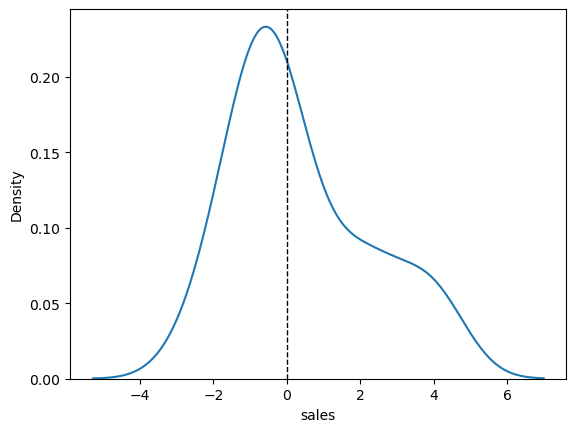

In [31]:
sns.kdeplot(y_pred-y_test)
plt.axvline(0, color='black', linestyle='--',linewidth=1)
plt.show()

### Without Scaling

In [7]:
model = linear_model.LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# Calculate the evaluation metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = (abs(y_test - y_pred) / y_test).mean() * 100  

print(f"R-squared: {r2}")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"Mean Absolute Percentage Error (MAPE): {mape}%")

R-squared: 0.899438024100912
Mean Absolute Error (MAE): 1.4607567168117606
Mean Squared Error (MSE): 3.1740973539761046
Root Mean Squared Error (RMSE): 1.7815996615334502
Mean Absolute Percentage Error (MAPE): 15.198846602831228%


In [10]:
# Perform cross-validation
cv_scores = cross_val_score(model, X, y, cv=5, scoring='neg_mean_squared_error')  # 5-fold CV

# Convert negative MSE to positive
cv_scores = np.abs(cv_scores)

# Calculate mean and standard deviation of MSE across folds
mean_cv_score = cv_scores.mean()
std_cv_score = cv_scores.std()
rmse_cv = np.sqrt(mean_cv_score)

# Print the results
print(f"Cross-Validation Mean Squared Error (MSE): {mean_cv_score}")
print(f"Cross-Validation RMSE: {rmse_cv}")
print(f"Cross-Validation Standard Deviation of MSE: {std_cv_score}")

Cross-Validation Mean Squared Error (MSE): 3.0729465971002092
Cross-Validation RMSE: 1.7529822010220781
Cross-Validation Standard Deviation of MSE: 1.2847825826540014


## Ridge(L2) & Lasso(L1) Regression

They both add a penalty term to the regression equation in order to prevent overfitting.

In Ridge regression: Cost Function = 1/2n [ Σ(Residual Error)^2 ] + λ(Slope)^2

1. This helps in overfitting.
2. NO feature selection, assumes all features are somewhat important.

In Lasso Regression: Cost Function = 1/2n [ Σ(Residual Error)^2 ] + λ|Slope|

1. This also helps in overfitting.
2. Helps in feature selection as all non important features are basically reduced to 0.

### Ridge

In [19]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

In [22]:
ridge = Ridge()

In [23]:
parameters = {'alpha':[1,2,5,10,20,30,40,50,60,70,80,90]}
ridgecv = GridSearchCV(ridge,parameters,scoring='neg_mean_squared_error',cv=5)
ridgecv.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=Ridge(),
             param_grid={'alpha': [1, 2, 5, 10, 20, 30, 40, 50, 60, 70, 80,
                                   90]},
             scoring='neg_mean_squared_error')

In [25]:
print(ridgecv.best_params_)

{'alpha': 1}


In [26]:
print(ridgecv.best_score_)

-2.9433931237278395


In [28]:
ridge_pred = ridgecv.predict(X_test)

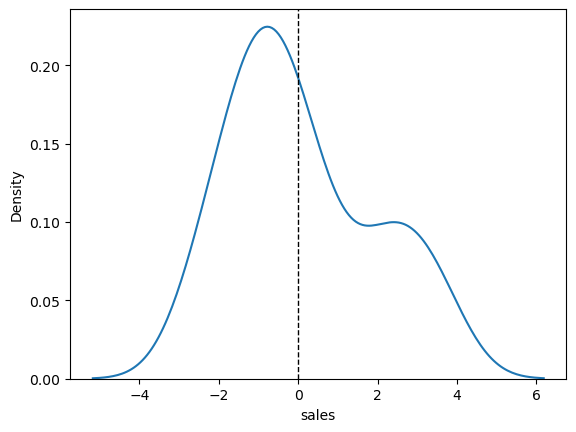

In [50]:
sns.kdeplot(ridge_pred-y_test)
plt.axvline(x=0, linestyle='--', linewidth=1, color='black')
plt.show()

In [32]:
score = r2_score(ridge_pred,y_test)
score

0.8791049542584577

### Lasso

In [ ]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV

In [41]:
lasso = Lasso()

In [42]:
parameters = {'alpha':[1,2,5,10,20,30,40,50,60,70,80,90]}
lassocv = GridSearchCV(lasso,parameters,scoring='neg_mean_squared_error',cv=5)
lassocv.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=Lasso(),
             param_grid={'alpha': [1, 2, 5, 10, 20, 30, 40, 50, 60, 70, 80,
                                   90]},
             scoring='neg_mean_squared_error')

In [43]:
print(lassocv.best_params_)

{'alpha': 1}


In [44]:
print(lassocv.best_score_)

-2.9195474714256


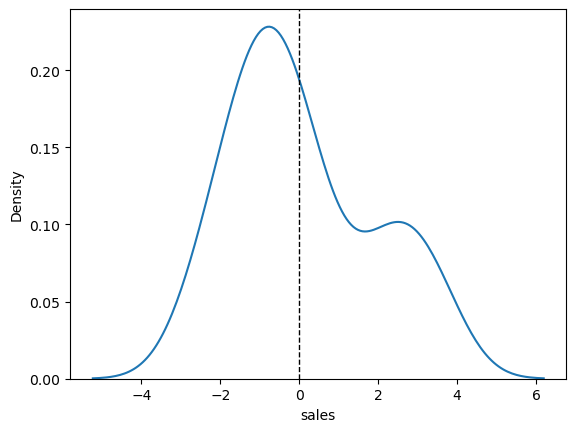

In [49]:
lasso_pred = lassocv.predict(X_test)
sns.kdeplot(lasso_pred-y_test)
plt.axvline(x=0, linestyle='--', linewidth=1, color='black')
plt.show()

## ElasticNet Regression

ElasticNet is a combination of both ridge and lasso regression. <br/>
It adds both the penalty terms to residual error. <br/>
1/2n [ Σ(Residual Error)^2 ] + λ(Slope)^2 + λ|Slope|

In [14]:
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV

In [15]:

elasticnet = ElasticNet()

parameters = {
    'alpha': [0.1, 1, 10, 100],  # Regularization strength
    'l1_ratio': [0.1, 0.5, 0.7, 1]  # Mix ratio between L1 and L2 penalties
}

elasticnet_cv = GridSearchCV(elasticnet, parameters, scoring='neg_mean_squared_error', cv=5)
elasticnet_cv.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=ElasticNet(),
             param_grid={'alpha': [0.1, 1, 10, 100],
                         'l1_ratio': [0.1, 0.5, 0.7, 1]},
             scoring='neg_mean_squared_error')

In [16]:
print(f"Best Parameters: {elasticnet_cv.best_params_}")


Best Parameters: {'alpha': 1, 'l1_ratio': 1}


In [17]:
print(f"Best Score: {elasticnet_cv.best_score_}")


Best Score: -2.9195474714256


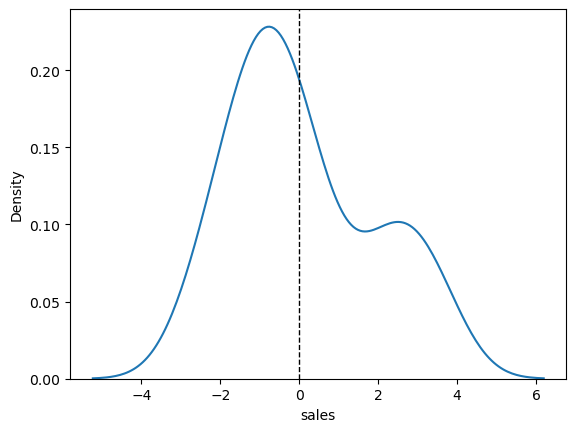

In [18]:
elasticnet_pred = elasticnet_cv.predict(X_test)
sns.kdeplot(elasticnet_pred - y_test)
plt.axvline(x=0, linestyle='--', linewidth=1, color='black')
plt.show()

In [19]:
r2 = r2_score(y_test, elasticnet_pred)
mae = mean_absolute_error(y_test, elasticnet_pred)
mse = mean_squared_error(y_test, elasticnet_pred)
rmse = np.sqrt(mse)

print(f"R-squared: {r2}")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")

R-squared: 0.9004013443377963
Mean Absolute Error (MAE): 1.452202278593457
Mean Squared Error (MSE): 3.143691505367936
Root Mean Squared Error (RMSE): 1.7730458272046823


In [32]:
# Perform cross-validation
cv_scores = cross_val_score(elasticnet, X, y, cv=5, scoring='neg_mean_squared_error')  # 5-fold CV

# Convert negative MSE to positive
cv_scores = np.abs(cv_scores)

# Calculate mean and standard deviation of MSE across folds
mean_cv_score = cv_scores.mean()
std_cv_score = cv_scores.std()
rmse_cv = np.sqrt(mean_cv_score)

# Print the results
print(f"Cross-Validation Mean Squared Error (MSE): {mean_cv_score}")
print(f"Cross-Validation RMSE: {rmse_cv}")
print(f"Cross-Validation Standard Deviation of MSE: {std_cv_score}")

Cross-Validation Mean Squared Error (MSE): 3.0542726942391836
Cross-Validation RMSE: 1.7476477603450826
Cross-Validation Standard Deviation of MSE: 1.2473331992099606
